Handling Imbalance DataSet

there are 2 techniques to handle the Imbalance dataset
1. Up Sampling
2. Down Sampling

In [3]:
import numpy as np
import pandas as pd

In [8]:
# Set random seed for reproducibility
np.random.seed(123)

# Create a sample dataset with 1000 samples and 20 features
n_samples = 1000
class_0_ratio = 0.9  # 90% of samples belong to class 0
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0  # Remaining samples belong to class 1

In [9]:
n_class_0, n_class_1

(900, 100)

In [13]:
# Create my dataset with imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0]*n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_1),
    'target': [1]*n_class_1
})

class_0


,feature_1,feature_2,target
0,0.226907,-0.525923,0
1,-2.398554,0.229579,0
2,-0.447858,-0.560087,0
3,0.197384,1.115389,0
4,0.627365,0.698765,0
...,...,...,...
895,1.558220,0.674080,0
896,-0.534894,-1.652091,0
897,1.178289,0.706091,0
898,0.168030,-0.542375,0


In [16]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df.tail()

,feature_1,feature_2,target
995,-1.877167,0.758545,1
996,0.862814,0.582465,1
997,0.733225,-1.607035,1
998,-0.657433,-0.390761,1
999,-0.157614,1.144320,1


In [17]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

Up-Sampling

up-sample this min = 100 data points to 900 max data points by adding some data points in this case

In [19]:
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [25]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority,replace=True, n_samples=len(df_majority),random_state=42)

In [28]:
df_minority_upsampled.shape
df_minority_upsampled.head()

,feature_1,feature_2,target
951,-0.279536,2.175706,1
992,-0.072572,1.018077,1
914,0.850840,0.058938,1
971,-0.463583,-1.046729,1
960,-0.802038,0.512859,1


In [30]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

Down-Sampling

Down-sample this max = 900 data points to 100 min data points by removing some data points in this case

In [32]:
# Set random seed for reproducibility
np.random.seed(123)

# Create a sample dataset with 1000 samples and 20 features
n_samples = 1000
class_0_ratio = 0.9  # 90% of samples belong to class 0
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0  # Remaining samples belong to class 1

# Create my dataset with imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0]*n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_1),
    'target': [1]*n_class_1
})

class_0

df = pd.concat([class_0, class_1]).reset_index(drop=True)
print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [33]:
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [35]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority,replace=True, n_samples=len(df_minority),random_state=42)

In [36]:
df_majority_downsampled.shape
df_majority_downsampled.head()

df_downsampled = pd.concat([df_majority_downsampled,df_minority])
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

SMOT (Sythentic Minority Oversampling Technique) - UpSampling Technique


In [38]:
from sklearn.datasets import make_classification

In [41]:
x,y = make_classification(n_samples=1000, n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=12)

In [43]:
import pandas as pd
df_x = pd.DataFrame(x, columns=['feature_1', 'feature_2'])
df_y = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df_x, df_y], axis=1)
final_df.head()

,feature_1,feature_2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [45]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

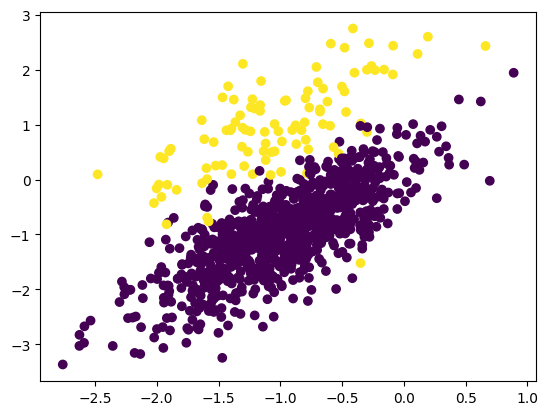

In [47]:
import matplotlib.pyplot as plt
plt.scatter(final_df['feature_1'], final_df['feature_2'], c=final_df['target'])

In [49]:
from imblearn.over_sampling import SMOTE


In [51]:
# transform the dataset
oversampler = SMOTE()
X,Y = oversampler.fit_resample(final_df[['feature_1','feature_2']], final_df['target'])

In [54]:
X.shape
Y.shape

(1800,)

In [56]:
df1 = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df2 = pd.DataFrame(Y, columns=['target'])
oversample_df = pd.concat([df1, df2], axis=1)

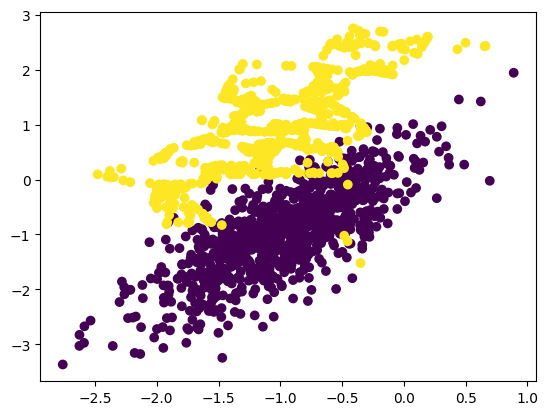

In [57]:
plt.scatter(oversample_df['feature_1'], oversample_df['feature_2'], c=oversample_df['target'])